In [1]:
import scipy as sp
from scipy.special import jv, hankel1, hankel2, yv, yvp, jvp
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index, pi, array, einsum, angle
from utils import hl1_prime, hl2_prime, h_z_cpa_numerator, h_z_cpa, e_z_cpa, h_z_recursive_cpa, e_z_recursive_cpa

### We look at the component of the Dyadic, $a^2\sum_{m\neq 0}\partial_y^2 G(0, m)=-\frac{i}{4}\sum_m \frac{2\pi a}{m\lambda}H_1^{(1)}(2\pi ma/\lambda)$, since we are interested with normal incidence with the electric field perpendicular to the cylinder axis.

In [3]:
# We define lambda in units of a 
def one_term_cylinder_yy(n, lambda_):
    kr = (2*pi/lambda_)*n
    coeff = -(1j/4)*(2*pi/n)/lambda_
    return coeff * hankel1(1, kr)

def closed_form_cylinder_yy_imaginary(lambda_):
    k = (2*pi/lambda_)
    return -k/2+k**2/8

### Note that the imaginary part of the lattice Green's function sum may be calculated analytically (which is what the function closed_form_cylinder_yy_imaginary does above). If $\lambda < a\leftrightarrow 2\pi < ka$, the result is especially simple. The result is derived by separating the lattice sum into two terms: $\sum_{m \neq 0}\Im\partial_y^2G(0, m)=\sum_{m} \Im\partial_y^2 G(0, m)- \Im\partial_y^2G(0, 0)$. Note that each of these terms is individually finite and they may be evaluated independently. The self-energy term gives:  $\lim_{\mathbf{r}\rightarrow\mathbf{r}_0}\partial_y^2\Im \text{G}(\mathbf{r}, \mathbf{r}_0)=\frac{1}{4}\partial_y^2J_0(k|\mathbf{r}-\mathbf{r}_0|)=\frac{1}{4}\Bigg[\frac{kJ_0'(kr)}{r}(1-(y/r)^2)+k^2(y/r)^2J_0''(kr)\Bigg]\\\approx -\frac{1}{8}k^2$. Furthermore, for the sum over all lattice sites, we have that $\sum_{m} \Im\partial_y^2 G(0, m) = \Im \partial_y^2 \frac{i}{2 (a\omega/c)}e^{iy\omega/c}\rightarrow-\frac{k}{2a}$. Therefore, we have that $a^2\sum_{m \neq 0}\Im\partial_y^2G(0, m)=-(ka)/2+(ka)^2/8$

In [37]:
M = 20
lambda_min = 1.1
lambda_max = 3
lambda_v = linspace(lambda_min, lambda_max, M)
N_v = [10, 20, 1000]
dipole_sums_cylinder_v = []
for (N_idx, N) in enumerate(N_v):
    print("N_idx: ", N_idx)
    dipole_sums_cylinder = zeros(M, dtype=complex)
    for (sum_idx, lambda_) in enumerate(lambda_v):
        dipole_sum = 0 
        for n in range(1, N+1):
            dipole_sum += 2*one_term_cylinder_yy(n, lambda_) # multiply by 2 to take in to account n->-n
        dipole_sums_cylinder[sum_idx] = dipole_sum
    dipole_sums_cylinder_v.append(dipole_sums_cylinder)

N_idx:  0
N_idx:  1
N_idx:  2


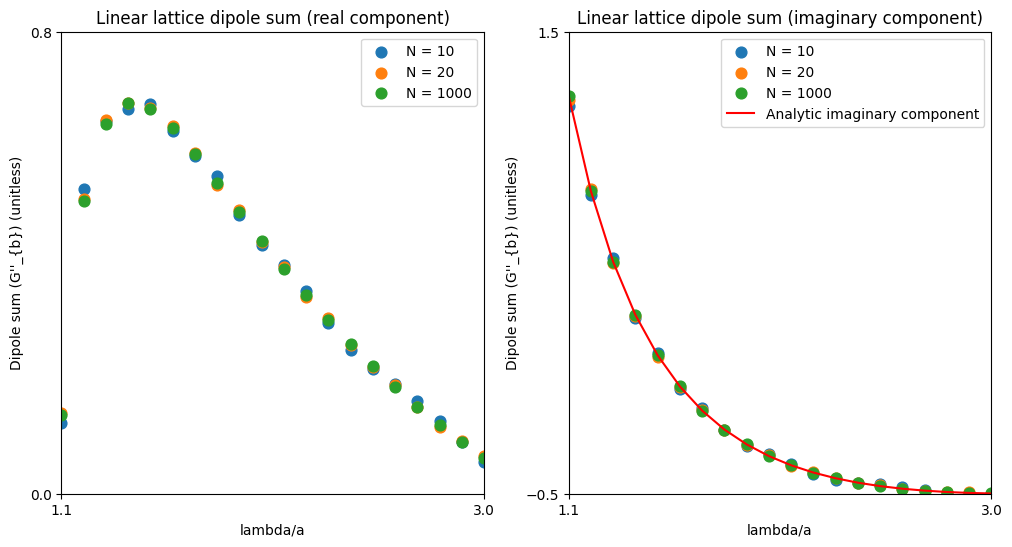

In [41]:
s = 60
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
for (N, dipole_sums_cylinder) in zip(N_v, dipole_sums_cylinder_v):
    #if N != 100000:
    #    continue
    ax1.scatter(lambda_v, dipole_sums_cylinder.real, label=f"N = {N}", s=s)    
    ax2.scatter(lambda_v, dipole_sums_cylinder.imag, label=f"N = {N}", s=s)
ax2.plot(lambda_v, closed_form_cylinder_yy_imaginary(lambda_v), linestyle="solid", color="red", label="Analytic imaginary component")
ax1.set_ylabel("Dipole sum (G''_{b}) (unitless)");
ax2.set_ylabel("Dipole sum (G''_{b}) (unitless)");

ax1.set_xlabel("lambda/a")
ax2.set_xlabel("lambda/a")

ax1.set_title("Linear lattice dipole sum (real component)");
ax2.set_title("Linear lattice dipole sum (imaginary component)");

ax1.legend();
ax1.set_xlim(lambda_v.min(), lambda_v.max());

ax2.legend();
ax2.set_xlim(lambda_v.min(), lambda_v.max());

ax1.set_xlim(lambda_min, lambda_max)
ax2.set_xlim(lambda_min, lambda_max)

ax1.set_ylim(0, 0.8)
ax2.set_ylim(-0.5, 1.5);

ax1.set_yticks([0, 0.8])
ax2.set_yticks([-0.5, 1.5])

ax1.set_xticks([lambda_min, lambda_max])
ax2.set_xticks([lambda_min, lambda_max]);
plt.savefig("./paper/lattice_sum.pdf")